# Experiment 5 (Week 2)

**Goal:** Measure how mergesort, heapsort, and quicksort runtimes changes as the imputs become less sorted.
We will use near sorted lists of fixed length and varry the number of ransom swaps to achive this. 


In [ ]:
import time
import statistics
import matplotlib.pyplot as plt
import sys
sys.setrecursionlimit(20000)  

from good_sorts import mergesort, heapsort, quicksort
from bad_sorts import create_near_sorted_list


In [ ]:
def time_sort(sort_fn, arr, runs=5):
    times = []
    for _ in range(runs):
        data = arr[:] 
        t0 = time.perf_counter()
        sort_fn(data)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return min(times)  

In [3]:
runs = 5
length = 5000
max_value = 10**6

swaps_values = [0, 1, 5, 10, 25, 50, 100, 250, 500, 1000, 2000]


In [7]:
merge_times = []
heap_times  = []
quick_times = []

for swaps in swaps_values:
    base = create_near_sorted_list(length, max_value, swaps)

    merge_times.append(time_sort(mergesort, base, runs))
    heap_times.append(time_sort(heapsort, base, runs))
    quick_times.append(time_sort(quicksort, base, runs))

merge_times, heap_times, quick_times


([0.019904799992218614,
  0.018285500118508935,
  0.017551800003275275,
  0.021536899963393807,
  0.01959999999962747,
  0.018397799925878644,
  0.01776630012318492,
  0.018802599981427193,
  0.01975709991529584,
  0.02027549990452826,
  0.0185631001368165],
 [0.054104499984532595,
  0.052707199938595295,
  0.05579459993168712,
  0.060612599831074476,
  0.05619579995982349,
  0.05333460005931556,
  0.050680499989539385,
  0.05441670003347099,
  0.05834560003131628,
  0.05440989998169243,
  0.05405830009840429],
 [1.0103575000539422,
  0.5838838999625295,
  0.39699920010752976,
  0.5262255000416189,
  0.18992400006391108,
  0.12833340000361204,
  0.07235960010439157,
  0.023089899914339185,
  0.016208800021559,
  0.01313289999961853,
  0.011784099973738194])

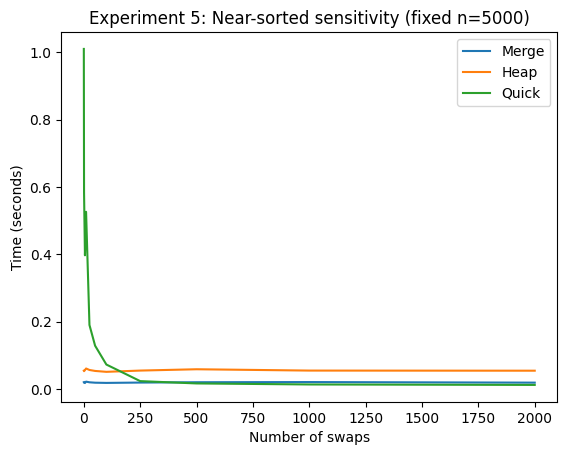

In [8]:
plt.figure()
plt.plot(swaps_values, merge_times, label="Merge")
plt.plot(swaps_values, heap_times,  label="Heap")
plt.plot(swaps_values, quick_times, label="Quick")
plt.xlabel("Number of swaps")
plt.ylabel("Time (seconds)")
plt.title("Experiment 5: Near-sorted sensitivity (fixed n=5000)")
plt.legend()
plt.show()


#Executive Summary
Qhen we have a fixed size array of values such as n = 5000 quick sort is very slow when the list is nearly sorted as there are very slow swaps, but its runtime drops sharply as the number of swaps increase and the input becomes more random. in contrast to that mergesort and heapsort stay reletivly the same regardless of how sorted the input data is. This shows that quick sort implmentationperforms poorly with near sorted data, while merge/heapsort provide a more consistent performance regardless of order. 